In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df9 = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

df9.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [2]:
df9.shape

(322, 8)

In [3]:
df9.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')

In [4]:
df9.dtypes

amfi_code              int64
stock_symbol             str
stock_name               str
sector                   str
weight_pct           float64
market_value_cr      float64
current_price_inr    float64
portfolio_date           str
dtype: object

In [5]:
df9["portfolio_date"] = pd.to_datetime(df9["portfolio_date"])

df9.dtypes

amfi_code                     int64
stock_symbol                    str
stock_name                      str
sector                          str
weight_pct                  float64
market_value_cr             float64
current_price_inr           float64
portfolio_date       datetime64[us]
dtype: object

In [6]:
df9.isnull().sum()

amfi_code            0
stock_symbol         0
stock_name           0
sector               0
weight_pct           0
market_value_cr      0
current_price_inr    0
portfolio_date       0
dtype: int64

In [7]:
df9.duplicated().sum()

np.int64(0)

In [8]:
df9.describe()

,amfi_code,weight_pct,market_value_cr,current_price_inr,portfolio_date
count,322.000000,322.000000,322.000000,322.000000,322
mean,121210.434783,10.558975,1008.846646,4080.870528,2025-12-31 00:00:00
min,100016.000000,0.990000,55.740000,246.780000,2025-12-31 00:00:00
25%,118633.000000,6.015000,513.702500,2081.985000,2025-12-31 00:00:00
50%,119552.000000,9.395000,1045.670000,4138.995000,2025-12-31 00:00:00
75%,120842.750000,13.917500,1477.502500,5914.307500,2025-12-31 00:00:00
max,149324.000000,38.180000,1999.500000,7942.960000,2025-12-31 00:00:00
std,14669.377920,6.060137,543.827535,2265.186353,NaN


In [9]:
sector_count = df9["sector"].value_counts()

sector_count

sector
Banking           60
IT                40
Pharma            38
Automobile        33
Utilities         24
Infrastructure    22
FMCG              21
Telecom           15
Diversified       14
Energy            13
Cement            12
NBFC              11
Paints            10
Consumer Goods     9
Name: count, dtype: int64

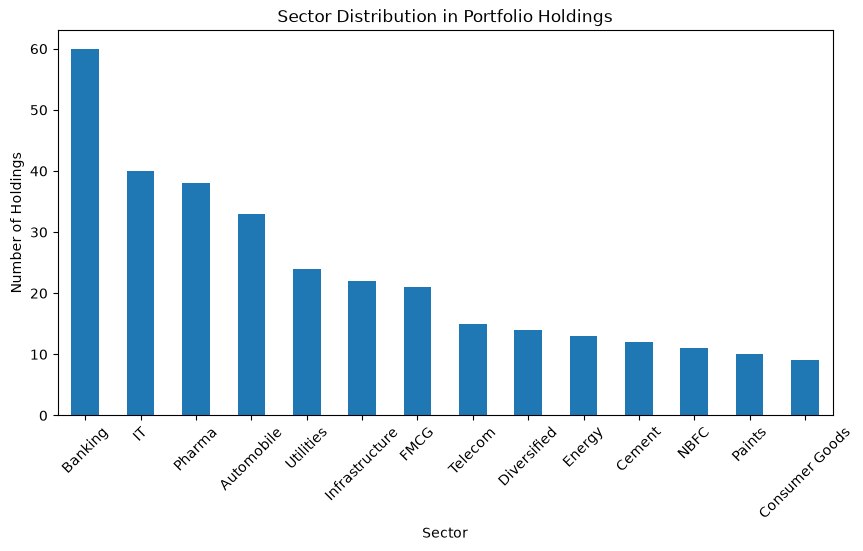

In [10]:
plt.figure(figsize=(10,5))

sector_count.plot(kind="bar")

plt.title("Sector Distribution in Portfolio Holdings")
plt.xlabel("Sector")
plt.ylabel("Number of Holdings")

plt.xticks(rotation=45)

plt.show()

In [11]:
top_stocks = df9.sort_values(
    by="weight_pct",
    ascending=False
).head(10)

top_stocks

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
183,119092,INFY,Infosys Ltd,IT,38.18,1254.80,3939.80,2025-12-31
229,101207,SUNPHARMA,Sun Pharmaceutical Industries,Pharma,35.07,285.75,5455.74,2025-12-31
118,118632,BHARTIARTL,Bharti Airtel Ltd,Telecom,30.44,1574.52,6271.17,2025-12-31
245,102885,NTPC,NTPC Ltd,Utilities,28.95,994.90,4140.59,2025-12-31
276,148568,SBIN,State Bank of India,Banking,28.61,498.31,2893.58,2025-12-31
40,119599,GRASIM,Grasim Industries Ltd,Diversified,28.25,1461.32,1872.83,2025-12-31
64,100033,M&M,Mahindra & Mahindra Ltd,Automobile,26.07,511.03,3852.87,2025-12-31
44,100016,WIPRO,Wipro Ltd,IT,25.90,552.43,579.31,2025-12-31
289,148569,BHARTIARTL,Bharti Airtel Ltd,Telecom,25.53,832.15,5736.45,2025-12-31
102,120505,SUNPHARMA,Sun Pharmaceutical Industries,Pharma,23.46,598.91,6868.09,2025-12-31


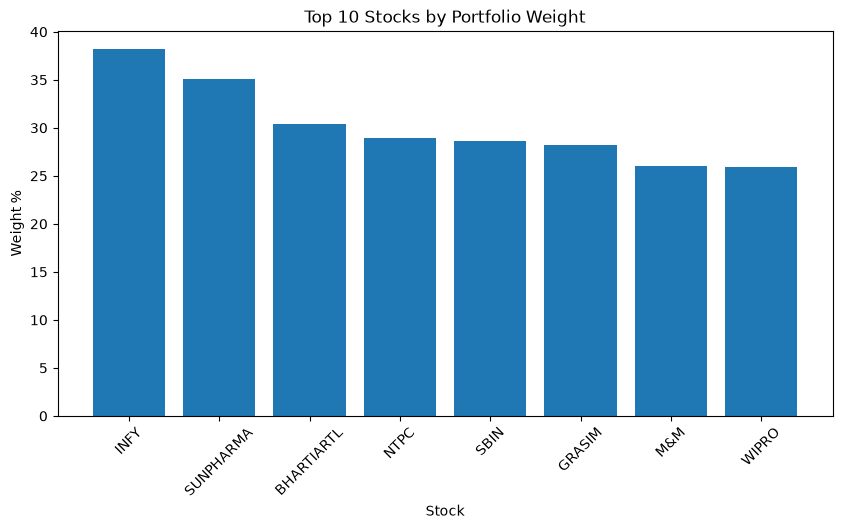

In [12]:
plt.figure(figsize=(10,5))

plt.bar(
    top_stocks["stock_symbol"],
    top_stocks["weight_pct"]
)

plt.title("Top 10 Stocks by Portfolio Weight")
plt.xlabel("Stock")
plt.ylabel("Weight %")

plt.xticks(rotation=45)

plt.show()

In [13]:
sector_value = (
    df9.groupby("sector")["market_value_cr"]
    .sum()
    .sort_values(ascending=False)
)

sector_value

sector
Banking           62840.29
IT                38477.11
Pharma            34606.10
Automobile        34296.97
Utilities         25108.63
Infrastructure    22433.39
FMCG              21151.15
Telecom           16051.45
Energy            15286.54
Diversified       13897.79
Cement            11611.97
Paints            10612.07
Consumer Goods     9859.70
NBFC               8615.46
Name: market_value_cr, dtype: float64

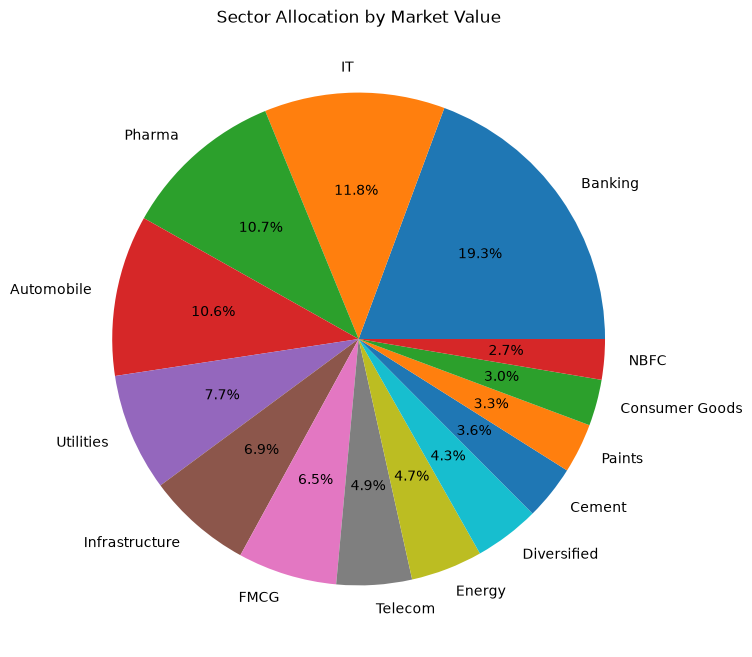

In [14]:
plt.figure(figsize=(8,8))

plt.pie(
    sector_value.values,
    labels=sector_value.index,
    autopct="%1.1f%%"
)

plt.title("Sector Allocation by Market Value")

plt.show()

In [18]:
top_market_value = (
    df9.groupby("stock_name")["market_value_cr"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_market_value

stock_name
Axis Bank Ltd              16325.94
Bharti Airtel Ltd          16051.45
Reliance Industries Ltd    15286.54
NTPC Ltd                   13951.43
Grasim Industries Ltd      13897.79
Hindustan Unilever Ltd     12993.93
Mahindra & Mahindra Ltd    12967.27
HCL Technologies Ltd       12299.86
Tata Motors Ltd            12296.77
UltraTech Cement Ltd       11611.97
Name: market_value_cr, dtype: float64

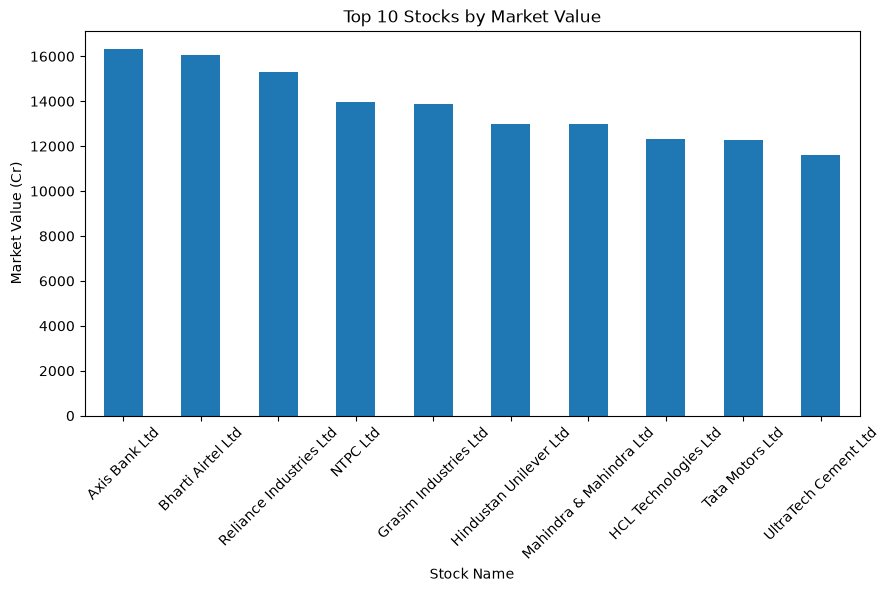

In [19]:
plt.figure(figsize=(10,5))

top_market_value.plot(kind="bar")

plt.title("Top 10 Stocks by Market Value")
plt.xlabel("Stock Name")
plt.ylabel("Market Value (Cr)")

plt.xticks(rotation=45)

plt.show()

In [20]:
sector_weight = (
    df9.groupby("sector")["weight_pct"]
    .mean()
    .sort_values(ascending=False)
)

sector_weight

sector
Consumer Goods    14.178889
Diversified       12.087857
IT                11.386750
Utilities         11.064167
FMCG              10.910000
Banking           10.871000
NBFC              10.826364
Pharma            10.722368
Automobile         9.807576
Telecom            9.708000
Energy             9.070000
Paints             8.986000
Cement             8.752500
Infrastructure     8.734545
Name: weight_pct, dtype: float64

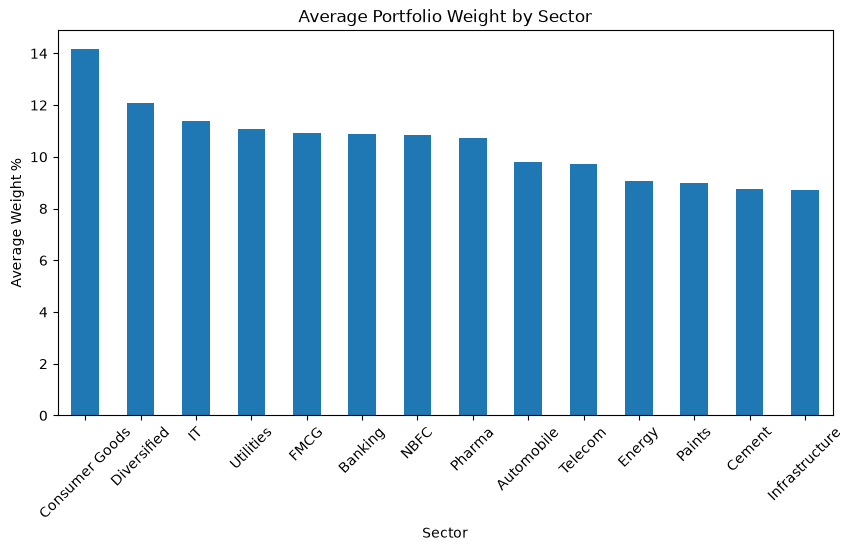

In [21]:
plt.figure(figsize=(10,5))

sector_weight.plot(kind="bar")

plt.title("Average Portfolio Weight by Sector")
plt.xlabel("Sector")
plt.ylabel("Average Weight %")

plt.xticks(rotation=45)

plt.show()

In [22]:
df9["current_price_inr"].describe()

count     322.000000
mean     4080.870528
std      2265.186353
min       246.780000
25%      2081.985000
50%      4138.995000
75%      5914.307500
max      7942.960000
Name: current_price_inr, dtype: float64

# Insights from Portfolio Holdings Dataset

## Dataset Overview
- Dataset contains portfolio holding details including stock names, sectors, weight percentage, market value, and current stock prices.
- Contains 322 records representing different mutual fund portfolio allocations.

## Data Quality
- Checked missing values and duplicate records.
- No missing values or duplicate entries were found.
- Numerical features such as weight percentage, market value, and current price were analyzed using descriptive statistics.

## Portfolio Analysis
- Sector-wise analysis shows diversification across multiple industries such as Banking, IT, Pharma, Automobile, Utilities, and FMCG.
- Market value analysis helps identify sectors and stocks contributing more to the overall portfolio.
- Weight percentage analysis highlights the major holdings with higher allocation in portfolios.

## Key Observation
Portfolio allocation is distributed across different sectors, reducing dependency on a single industry. The analysis helps identify major holdings, sector concentration, and investment patterns for better portfolio understanding.